In [1]:
# importa bibliotecas necessárias
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
# carrega dataset de fraude
fraud_df = pd.read_csv("fraud.csv")

print("FRAUD DATASET")
print(f"   Shape    : {fraud_df.shape[0]:,} rows x {fraud_df.shape[1]} columns")
print(f"   Missing  : {fraud_df.isnull().sum().sum()}")
print(f"   NaN      : {fraud_df.isna().sum().sum()}")

print("\nFRAUD COLUMNS")
print(f"   Columns  : {fraud_df.columns}")

FRAUD DATASET
   Shape    : 7,000 rows x 13 columns
   Missing  : 5600
   NaN      : 5600

FRAUD COLUMNS
   Columns  : Index(['transaction_amount', 'hour_of_day', 'is_weekend', 'num_items',
       'customer_age', 'prev_transactions', 'distance_from_home',
       'device_type', 'network_quality', 'is_first_transaction', 'store_type',
       'velocity_score', 'is_fraud'],
      dtype='object')


In [3]:
# substitui valores ausentes usando KNN
imp_knn =  KNNImputer(n_neighbors=12)
fraud_cols = fraud_df.columns

df_imputado = pd.DataFrame(
    imp_knn.fit_transform(
        fraud_df[fraud_cols]
    ),
    columns=fraud_cols,
)

print(f"   Missing         : {df_imputado.isnull().sum().sum()}")
print(f"   Total Count     : {df_imputado.count().sum().sum()}")
print(f"   Not Null Count  : {df_imputado.notnull().sum().sum()}")

   Missing         : 0
   Total Count     : 91000
   Not Null Count  : 91000


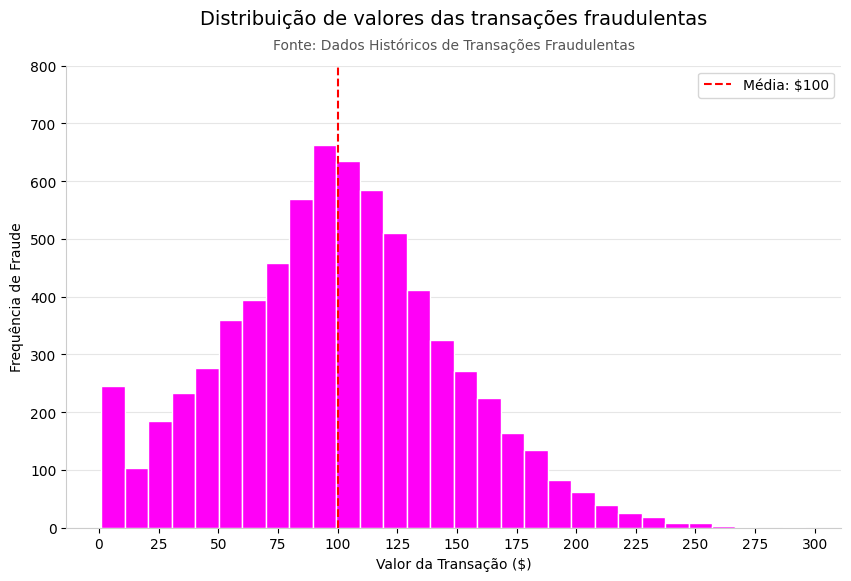

In [4]:
# plota histograma dos valores das transações
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_imputado["transaction_amount"], bins=30, color="#FF00F7", edgecolor="white")

ax.set_title('Distribuição de valores das transações fraudulentas', fontsize=14, pad=30)
ax.text(
    0.5,
    1.03,
    "Fonte: Dados Históricos de Transações Fraudulentas",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("Valor da Transação ($)")
ax.set_ylabel("Frequência de Fraude")
ax.set_ylim(0, 800)

# adiciona linha média no histograma
ax.axvline(
    df_imputado["transaction_amount"].mean(),
    color="red",
    linestyle="--",
    label=f"Média: ${df_imputado['transaction_amount'].mean():,.0f}",
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")

ax.grid(
    axis="y",
    color="#e6e6e6",
    linewidth=0.8
)
ax.set_axisbelow(True)

plt.legend()
plt.xticks(np.arange(0, 301, 25))
plt.savefig("Histograma de distribuição das transações fraudulentas.png", dpi=300)
plt.show()

In [5]:
# carrega dataset de risco de crédito BNPL
df_credit_risk = pd.read_csv("buy_now_pay_later_risk_dataset.csv")

print("CREDIT RISK DATASET")
print(f"   Shape    : {df_credit_risk.shape[0]:,} rows x {fraud_df.shape[1]} columns")
print(f"   Missing  : {df_credit_risk.isnull().sum().sum()}")
print(f"   NaN      : {df_credit_risk.isna().sum().sum()}")

print("\nCREDIT RISK COLUMNS")
print(f"   Columns  : {df_credit_risk.columns}")

print("\n CREDIT RISK COLUMN TYPES")
for col, dtype in df_credit_risk.dtypes.items():
    print(f"   {col}: {dtype}")

CREDIT RISK DATASET
   Shape    : 10,345 rows x 13 columns
   Missing  : 0
   NaN      : 0

CREDIT RISK COLUMNS
   Columns  : Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='object')

 CREDIT RISK COLUMN TYPES
   user_id: int64
   age: int64
   employment_type: object
   monthly_income: float64
   credit_score: int64
   purchase_amount: float64
   product_category: object
   bnpl_installments: int64
   repayment_delay_days: int64
   missed_payments: int64
   default_flag: int64
   app_usage_frequency: float64
   location: object
   transaction_date: object
   debt_to_income_ratio: float64
   risk_score: float64
   customer_segment: object


In [6]:
# remove colunas não necessárias para análise de correlação
int_cols_df_credit_risk = df_credit_risk.drop(
    columns=(
        [
            "employment_type",
            "product_category",
            "location",
            "transaction_date",
            "customer_segment",
            "user_id",
            "bnpl_installments",
            "app_usage_frequency",
        ]
    ),
    axis=1,
)

print("\nFORMATTED CREDIT RISK COLUMN TYPES")
for col, dtype in int_cols_df_credit_risk.dtypes.items():
    print(f"   {col}: {dtype}")


FORMATTED CREDIT RISK COLUMN TYPES
   age: int64
   monthly_income: float64
   credit_score: int64
   purchase_amount: float64
   repayment_delay_days: int64
   missed_payments: int64
   default_flag: int64
   debt_to_income_ratio: float64
   risk_score: float64


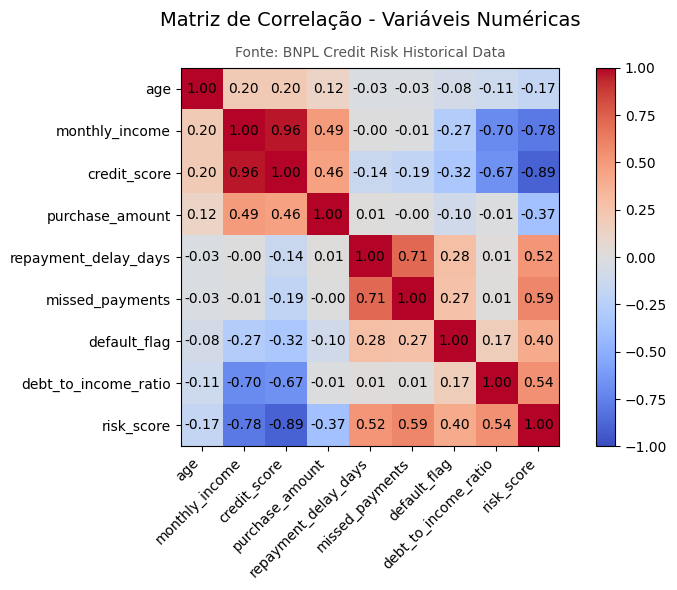

In [ ]:
# constrói heatmap da correlação entre variáveis
correlation = int_cols_df_credit_risk.corr().values
labels = int_cols_df_credit_risk.columns

fig, ax = plt.subplots(figsize=(10, 6))
heatmap = ax.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{correlation[i, j]:.2f}', ha='center', va='center', color='black')

ax.set_title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, pad=30)
ax.text(
    0.5,
    1.02,
    "Fonte: BNPL Credit Risk Historical Data",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

plt.colorbar(heatmap, ax=ax)
plt.tight_layout()
fig.subplots_adjust(left=0.10, right=0.83)
plt.savefig("Matriz de Correlação de Risco de Crédito.png", dpi=300)
plt.show()

In [8]:
# carrega e inspeciona os datasets de sono e burnout
burn_df = pd.read_csv("mental_health_burnout_tech_2026.csv")
sleep_df = pd.read_csv("sleep_health_dataset.csv")

print('SLEEP HEALTH DATASET')
print(f'   Shape    : {sleep_df.shape[0]:,} rows x {sleep_df.shape[1]} columns')
print(f'   Missing  : {sleep_df.isnull().sum().sum()}')
print(f'   NaN      : {sleep_df.isna().sum().sum()}')

print('\nMENTAL HEALTH & BURNOUT DATASET')
print(f'   Shape    : {burn_df.shape[0]:,} rows x {burn_df.shape[1]} columns')
print(f'   Missing  : {burn_df.isnull().sum().sum()}')
print(f'   NaN      : {burn_df.isna().sum().sum()}')

print('\nSLEEP COLUMNS')
print(f'   Columns  : {sleep_df.columns}')

print('\nMENTAL HEALTH & BURNOUT DATASET')
print(f'   Columns  : {burn_df.columns}')



SLEEP HEALTH DATASET
   Shape    : 100,000 rows x 32 columns
   Missing  : 0
   NaN      : 0

MENTAL HEALTH & BURNOUT DATASET
   Shape    : 100,000 rows x 36 columns
   Missing  : 0
   NaN      : 0

SLEEP COLUMNS
   Columns  : Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

MENTAL HEALTH & BURNOUT DATASET
   Columns  : Inde

Sample Sleep Shape: 5,000 rows x 32 columns
Sample Burnout Shape: 5,000 rows x 36 columns


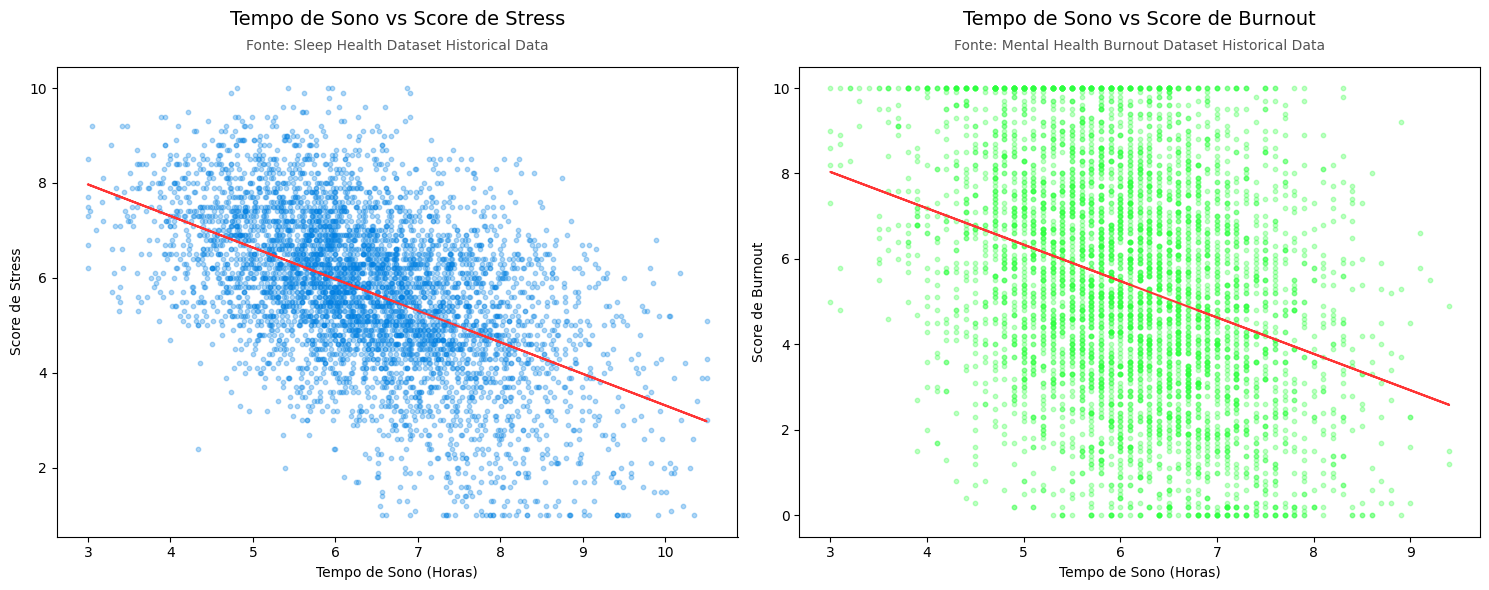

In [10]:
# cria gráficos de regressão para relações entre sono e burnout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample_sleep = sleep_df.sample(5000, random_state=42)
print(f"Sample Sleep Shape: {sample_sleep.shape[0]:,} rows x {sample_sleep.shape[1]} columns")

X_sleep = sample_sleep[["sleep_duration_hrs"]]
y_sleep = sample_sleep["stress_score"]

reg_sleep = LinearRegression()
reg_sleep.fit(X_sleep, y_sleep)
predictions_sleep = reg_sleep.predict(X_sleep)

axes[0].plot(X_sleep, predictions_sleep, color="#FF3434")
axes[0].scatter(X_sleep, y_sleep, alpha=0.30, s=10, color="#0080E2")

axes[0].set_title("Tempo de Sono vs Score de Stress", fontsize=14, pad=30)
axes[0].text(
    0.50,
    1.03,
    "Fonte: Sleep Health Dataset Historical Data",
    transform=axes[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

axes[0].set_xlabel("Tempo de Sono (Horas)")
axes[0].set_ylabel("Score de Stress")

sample_burn = burn_df.sample(5000, random_state=42)
print(f"Sample Burnout Shape: {sample_burn.shape[0]:,} rows x {sample_burn.shape[1]} columns")

X_burn = sample_burn[["sleep_hours_per_night"]]
y_burn = sample_burn["burnout_score"]

reg_burn = LinearRegression()
reg_burn.fit(X_burn, y_burn)
predictions_burn = reg_burn.predict(X_burn)

axes[1].plot(X_burn, predictions_burn, color="#FF3434")
axes[1].scatter(X_burn, y_burn, alpha=0.30, s=10, color="#2DFF3F")

axes[1].set_title("Tempo de Sono vs Score de Burnout", fontsize=14, pad=30)
axes[1].text(
    0.50,
    1.03,
    "Fonte: Mental Health Burnout Dataset Historical Data",
    transform=axes[1].transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

axes[1].set_xlabel("Tempo de Sono (Horas)")
axes[1].set_ylabel("Score de Burnout")

plt.tight_layout()
plt.savefig("Gráfico de Dispersão Sleep & Burnout.png", dpi=300)
plt.show()